In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Load Your Data ---
# Assuming your dataset is named 'dataset2.csv'
df = pd.read_csv('C:/Users/USER/MPU5060_1DCNN_MODEL/final_training_dataset.csv')

# Select features: ax, ay, az, gx, gy, gz, vib
features = ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'vib']
X = df[features].values
y = df['label'].values

# --- Windowing Function ---
def create_windows(X, y, window_size=100, step_size=50):
    X_windows = []
    y_windows = []
    for i in range(0, len(X) - window_size, step_size):
        X_windows.append(X[i:i + window_size])
        # Use the most common label in the window
        y_windows.append(np.bincount(y[i:i + window_size]).argmax())
    return np.array(X_windows), np.array(y_windows)

# Create 100-sample windows (approx 0.1s to 0.2s of data based on your timestamps)
X_win, y_win = create_windows(X, y, window_size=100, step_size=50)

# Split into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X_win, y_win, test_size=0.2, random_state=42)

In [16]:
def build_1d_cnn(input_shape, num_classes):
    model = models.Sequential([
        # First Conv Layer: Detects local patterns in the sensor stream
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        # Second Conv Layer: Detects more complex vibration signatures
        layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
        layers.Dropout(0.3),
        layers.MaxPooling1D(pool_size=2),
        
        # Flatten and Dense Layers for classification
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax') # softmax for multi-class
    ])
    
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

# Initialize the model
# input_shape = (window_size, number_of_features)
input_shape = (X_train.shape[1], X_train.shape[2]) 
num_classes = len(np.unique(y_win))

model = build_1d_cnn(input_shape, num_classes)
model.summary()

c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 98, 64)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 98, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 49, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 47, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       188,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,978 (839.76 KB)

 Trainable params: 214,850 (839.26 KB)

 Non-trainable params: 128 (512.00 B)

In [17]:
# Train the model
history = model.fit(X_train, y_train, 
                    epochs=20, 
                    batch_size=32, 
                    validation_split=0.1)

# Evaluate on unseen data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Save for your GUI or Real-time detection
model.save('mpu6050_motor_model.h5')

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5104 - loss: 0.8292 - val_accuracy: 0.5437 - val_loss: 0.6901
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5633 - loss: 0.6884 - val_accuracy: 0.5437 - val_loss: 0.7455
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5640 - loss: 0.6755 - val_accuracy: 0.4187 - val_loss: 0.7029
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6134 - loss: 0.6577 - val_accuracy: 0.4812 - val_loss: 0.7391
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6509 - loss: 0.6182 - val_accuracy: 0.4375 - val_loss: 0.8371
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7170 - loss: 0.5680 - val_accuracy: 0.4375 - val_loss: 0.8132
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7858 - loss: 0.4874 - val_accuracy: 0.4500 - val_loss: 0.9239
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8060 - loss: 0.4277 - val_accuracy: 0.4688 - v

Test Accuracy: 50.75%


In [18]:
# Save the trained model
model_name = 'mpu6050_cnn_v1.h5'
model.save(model_name)
print(f"✅ Model saved as {model_name}")

# Save accuracy to a text file
with open('model_metrics.txt', 'w') as f:
    f.write(f"Final Test Accuracy: {test_acc*100:.2f}%\n")
    f.write(f"Final Test Loss: {test_loss:.4f}\n")

✅ Model saved as mpu6050_cnn_v1.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


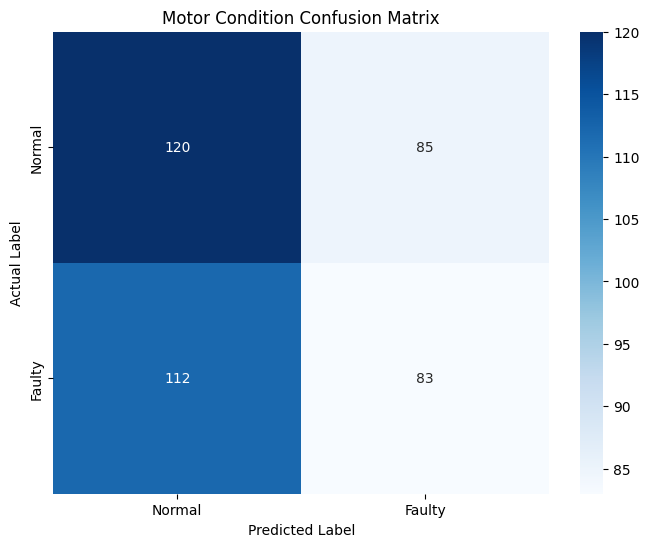


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.52      0.59      0.55       205
           1       0.49      0.43      0.46       195

    accuracy                           0.51       400
   macro avg       0.51      0.51      0.50       400
weighted avg       0.51      0.51      0.50       400



In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions from the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Faulty'], # Update these based on your labels
            yticklabels=['Normal', 'Faulty'])
plt.title('Motor Condition Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Print detailed report (Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

In [20]:
import pandas as pd
import numpy as np

# Load your original 1001-row dataset
df_real = pd.read_csv(r'C:/Users/USER/MPU5060_1DCNN_MODEL/synthetic_motor_data.csv')

# Calculate statistics for each sensor column
stats = df_real[['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'vib']].agg(['mean', 'std', 'min', 'max'])
print("--- Dataset Statistics ---")
print(stats)

--- Dataset Statistics ---
            ax        ay        az         gx          gy         gz       vib
mean  0.961244  0.004903 -0.168376  -0.121985    6.701791   0.921657  1.036268
std   0.284090  0.110707  0.314813  10.128731   38.253266   8.816285  0.249135
min  -0.268062 -0.408599 -1.472494 -41.826656 -155.989317 -34.666257  0.235458
max   2.000000  0.442946  0.985933  40.336360  165.728003  35.971986  2.040999


In [21]:
import pandas as pd
from pathlib import Path

# Load your normal and faulty synthetic datasets
df_normal = pd.read_csv('synthetic_motor_data_normal.csv')
df_faulty = pd.read_csv('synthetic_motor_data_faulty.csv')

# Merge them together
# ignore_index=True prevents duplicate row numbers
df_combined = pd.concat([df_normal, df_faulty], ignore_index=True)

# Shuffle the data 
# This is critical so the model doesn't see all 'Normal' then all 'Faulty'
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

# Save your final training dataset
df_combined.to_csv('final_training_dataset.csv', index=False)

print(f"✅ Success! New dataset created with {len(df_combined)} total rows.")
print(f"Normal samples: {len(df_normal)}")
print(f"Faulty samples: {len(df_faulty)}")

✅ Success! New dataset created with 100000 total rows.
Normal samples: 50000
Faulty samples: 50000


In [22]:
# --- CONFIGURATION ---
num_new_rows = 50000
target_label = 1  # 0 for Normal, 1 for Faulty (change as needed)

synthetic_data = {}

# Generate time column (continuing from where your data left off)
start_time = df_real['time'].iloc[-1] + 0.01
synthetic_data['time'] = np.linspace(start_time, start_time + (num_new_rows * 0.01), num_new_rows)

# Generate sensor columns based on real stats
for col in ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'vib']:
    # Generate random values using the Mean and Std Dev of your real data
    new_values = np.random.normal(loc=stats[col]['mean'], 
                                  scale=stats[col]['std'], 
                                  size=num_new_rows)
    
    # Clip values to ensure they don't exceed the physical MPU6050 limits
    synthetic_data[col] = np.clip(new_values, stats[col]['min'], stats[col]['max'])

# Add the label
synthetic_data['label'] = [target_label] * num_new_rows

# Create the new DataFrame
df_synthetic = pd.DataFrame(synthetic_data)

# Save it to a new CSV
df_synthetic.to_csv('synthetic_motor_data_faulty.csv', index=False)
print(f"✅ Generated {num_new_rows} rows of synthetic data in 'synthetic_motor_data.csv'")

✅ Generated 50000 rows of synthetic data in 'synthetic_motor_data.csv'
